# CardioIA, Fase 2: Diagnóstico Automatizado, IA no Estetoscópio Digital

## Classificador de risco com TF-IDF (Parte 2) e integração com o extrator de sintomas (Parte 1)

| Item | Valor |
|---|---|
| Curso | FIAP, Inteligência Artificial, 2º ano |
| Fase | 2, "Diagnóstico Automatizado, IA no Estetoscópio Digital" |
| Grupo | Grupo 69 |
| Integrantes | Silvio Prestes Guerreiro Junior (RM567958) |
| Tutor | Leonardo Ruiz Orabona |
| Coordenador | André Godoi Chiovato |

**Objetivo.** Treinar e avaliar um classificador de texto que estima o nível de risco (`alto risco` ou `baixo risco`) de frases curtas em que pacientes descrevem seus sintomas, usando representação TF-IDF e modelos clássicos do Scikit-learn: Regressão Logística como modelo principal, Árvore de Decisão e Naive Bayes como comparativos. Ao final, o classificador é integrado ao extrator de sintomas da Parte 1 na função `triagem(frase)`, que devolve os sintomas reconhecidos, a hipótese diagnóstica sugerida e o nível de risco.

**Aviso de uso acadêmico.** Este notebook é um exercício da disciplina, construído com frases sintéticas criadas pelo grupo e rotuladas sem validação clínica. Nenhum resultado aqui apresentado pode ser usado como ferramenta de diagnóstico ou de triagem real. O sistema não substitui a avaliação de um profissional de saúde.

**Como executar.** Localmente (Jupyter, JupyterLab ou VS Code): instalar as dependências com `pip install -r config/requirements.txt`, abrir este arquivo a partir da pasta `src/notebooks/` do repositório e usar "Reiniciar e executar tudo". No Google Colab: executar as duas linhas abaixo em uma célula antes de tudo (descomentadas), o que clona o repositório e entra na pasta `src/notebooks/`.

```python
# !git clone https://github.com/silvioguerreiro/FIAP_2TIAOR_2026_Ano2_Fase2.git
# %cd FIAP_2TIAOR_2026_Ano2_Fase2/src/notebooks
```

## 1. Ambiente

Bibliotecas, versões e semente global de reprodutibilidade (`RANDOM_STATE = 42`, usada em toda operação aleatória: divisão treino/teste, validação cruzada e modelos). Os caminhos são relativos à raiz do repositório, localizada automaticamente a partir da pasta atual.

In [1]:
import inspect
import platform
import re
import sys
import textwrap
import unicodedata
from pathlib import Path

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from matplotlib.patches import Patch
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                             make_scorer, precision_score, recall_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold, cross_val_score,
                                     cross_validate, train_test_split)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, export_text

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def localizar_raiz():
    """Sobe a partir da pasta atual ate encontrar data/frases_risco.csv (raiz do repositorio)."""
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "data" / "frases_risco.csv").exists():
            return candidato
    raise FileNotFoundError("Raiz do repositorio nao encontrada. No Colab, clone o repositorio "
                            "e entre na pasta src/notebooks/ antes de executar (ver celula inicial).")


RAIZ = localizar_raiz()
DIR_DADOS = RAIZ / "data"
DIR_ASSETS = RAIZ / "assets"
DIR_MODELOS = RAIZ / "src" / "models"
DIR_ASSETS.mkdir(exist_ok=True)
DIR_MODELOS.mkdir(exist_ok=True)
sys.path.insert(0, str(RAIZ / "src"))      # extrator_sintomas (Parte 1)
sys.path.insert(0, str(RAIZ / "scripts"))  # gerar_frases_risco (categorias das frases de teste)

pd.set_option("display.max_colwidth", 110)
pd.set_option("display.width", 160)

# Paleta e estilo das figuras (cores por classe, texto em tons neutros)
CORES = {"alto risco": "#eb6834", "baixo risco": "#2a78d6"}
TEXTO, TEXTO_SEC, GRADE = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 150, "font.size": 10,
    "axes.edgecolor": GRADE, "axes.labelcolor": TEXTO_SEC, "axes.titlecolor": TEXTO,
    "xtick.color": TEXTO_SEC, "ytick.color": TEXTO_SEC,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.facecolor": "white", "axes.facecolor": "white",
})

print(f"Python {platform.python_version()} | pandas {pd.__version__} | numpy {np.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {matplotlib.__version__}")
print(f"Raiz do repositorio localizada (pastas data/, src/, scripts/ e assets/ acessiveis) | RANDOM_STATE = {RANDOM_STATE}")

Python 3.11.15 | pandas 3.0.2 | numpy 2.4.4 | scikit-learn 1.8.0 | matplotlib 3.10.9
Raiz do repositorio localizada (pastas data/, src/, scripts/ e assets/ acessiveis) | RANDOM_STATE = 42


## 2. Carga e exploração da base rotulada

A base `data/frases_risco.csv` foi gerada por `scripts/gerar_frases_risco.py` (100 frases, 50 por classe, cabeçalho `frase,situacao`). Os critérios de rotulagem, os casos-limite e os vieses conhecidos estão em `document/criterios_rotulagem.md`.

In [2]:
# Carrega a base rotulada e confere o formato exigido pelo enunciado (cabecalho, rotulos, sem duplicatas)
df = pd.read_csv(DIR_DADOS / "frases_risco.csv")
assert list(df.columns) == ["frase", "situacao"], "cabecalho inesperado"
assert set(df["situacao"]) == {"alto risco", "baixo risco"}, "rotulos inesperados"
assert df["frase"].is_unique, "frases duplicadas"

print("Dimensao da base:", df.shape)
print("\nDistribuicao das classes:")
print(df["situacao"].value_counts().to_string())
display(df.sample(8, random_state=RANDOM_STATE).reset_index(drop=True))

Dimensao da base: (100, 2)

Distribuicao das classes:
situacao
alto risco     50
baixo risco    50


,frase,situacao
0,Estou com dor no braço direito depois de pintar a parede ontem.,baixo risco
1,Meu coração bate descompassado e sinto que vou desmaiar a qualquer momento.,alto risco
2,Estou com uma dor forte no peito que espalha para o braço esquerdo e suor frio.,alto risco
3,"Minha pressão deu treze por oito hoje e me sinto bem, sem dor de cabeça.",baixo risco
4,"Boca torta, fala embolada e fraqueza em um lado do corpo, apareceu de repente.",alto risco
5,"Palpitação forte com tontura e a vista escurecendo, começou faz uma hora.",alto risco
6,Sinto um desconforto no estômago e arroto depois das refeições pesadas.,baixo risco
7,Estou nervoso com a entrevista de amanhã e sinto um frio na barriga.,baixo risco


In [3]:
# Comprimento das frases por classe (verifica se o tamanho da frase, sozinho, poderia denunciar o rotulo)
df["n_palavras"] = df["frase"].str.split().str.len()
df["n_caracteres"] = df["frase"].str.len()
resumo_comprimento = df.groupby("situacao")[["n_palavras", "n_caracteres"]].agg(["min", "mean", "max"]).round(1)
print("Comprimento das frases por classe:")
display(resumo_comprimento)

Comprimento das frases por classe:


n_palavras           n_caracteres           
                   min  mean max          min  mean  max
situacao                                                
alto risco           7  14.2  21           31  75.7  104
baixo risco          5  12.5  16           25  68.3   86

In [4]:
# Termos mais frequentes por classe (contagem simples, minusculas e sem acentos, sem remocao de stopwords)
contador = CountVectorizer(strip_accents="unicode", lowercase=True)
matriz_contagem = contador.fit_transform(df["frase"])
termos = contador.get_feature_names_out()
tabela_termos = {}
for classe in ["alto risco", "baixo risco"]:
    mascara = (df["situacao"] == classe).to_numpy()
    frequencias = np.asarray(matriz_contagem[mascara].sum(axis=0)).ravel()
    ordem = frequencias.argsort()[::-1][:15]
    tabela_termos[classe] = [f"{termos[i]} ({frequencias[i]})" for i in ordem]
print("Quinze termos mais frequentes por classe (termo e numero de ocorrencias):")
display(pd.DataFrame(tabela_termos))

Quinze termos mais frequentes por classe (termo e numero de ocorrencias):


,alto risco,baixo risco
0,de (30),de (40)
1,com (29),no (23)
2,peito (26),depois (22)
3,no (26),dor (21)
4,dor (25),um (17)
5,ar (14),sinto (15)
6,falta (14),quando (14)
7,uma (13),com (12)
8,frio (13),leve (11)
9,que (12),sem (10)


## 3. Pré-processamento

O pré-processamento é feito dentro do próprio `TfidfVectorizer`, o que garante o mesmo tratamento no treino, no teste e em qualquer frase nova:

| Etapa | Parâmetro | Efeito |
|---|---|---|
| Minúsculas | `lowercase=True` | "Dor" e "dor" viram o mesmo termo |
| Remoção de acentos | `strip_accents="unicode"` | "coração", "coraçao" e "coracao" viram `coracao`, o que absorve parte dos erros de digitação |
| Tokenização | `token_pattern` padrão `(?u)\b\w\w+\b` | separa palavras com dois ou mais caracteres; a pontuação é descartada |
| Stopwords | lista mínima em português | remove artigos, preposições, pronomes e as conjunções "e", "ou" e "que" |

A lista de stopwords é deliberadamente curta e **preserva "não", "sem", "nem" e "nunca"**: removê-las faria "não sinto dor no peito" e "sinto dor no peito" produzirem o mesmo vetor. Também preserva advérbios e verbos de apoio ("só", "depois", "agora", "mesmo", "sinto", "passou"), porque em frases curtas de sintomas essas palavras carregam contexto de gravidade: "só quando aperto" e "depois de comer" apontam para baixo risco, "começou agora" e "mesmo parado" para alto risco. A seção 6.1 mede esse efeito comparando três listas por validação cruzada.

In [5]:
STOPWORDS_PT = sorted({
    "a", "o", "as", "os", "um", "uma", "uns", "umas",
    "de", "do", "da", "dos", "das", "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "para", "pra", "pro", "com", "ao", "aos",
    "que", "e", "ou",
    "meu", "minha", "meus", "minhas", "seu", "sua",
    "eu", "ele", "ela", "me", "isso", "isto", "esse", "essa", "este", "esta",
})
# Lista ampla, usada apenas na comparacao da secao 6.1 (inclui verbos de apoio e adverbios)
STOPWORDS_AMPLA = sorted(set(STOPWORDS_PT) | {
    "mas", "se", "eles", "elas", "te", "lhe", "aquele", "aquela", "ja", "so", "bem", "mais", "tambem",
    "ate", "depois", "antes", "quando", "onde", "como", "porque", "hoje", "ontem", "agora", "dia",
    "dias", "hora", "horas", "semana", "ha", "faz", "fico", "fiquei", "estou", "esta", "estao",
    "tenho", "tem", "sinto", "senti", "sou", "era", "foi", "ser", "ter", "vem", "veio", "vai", "vou",
    "la", "aqui", "tudo", "nada", "algo", "ainda", "logo", "mesmo",
})
NEGACOES = {"nao", "sem", "nem", "nunca", "nenhum", "nenhuma"}
assert not NEGACOES & set(STOPWORDS_PT) and not NEGACOES & set(STOPWORDS_AMPLA)

PARAMETROS_TFIDF = dict(
    lowercase=True,
    strip_accents="unicode",
    stop_words=STOPWORDS_PT,
    ngram_range=(1, 2),   # unigramas e bigramas
    min_df=2,             # termo precisa aparecer em ao menos duas frases
    norm="l2",            # vetores normalizados: frases longas nao pesam mais
    sublinear_tf=False,   # frases curtas raramente repetem termos
)

exemplo = df.loc[df["frase"].str.startswith("Não sinto dor no peito"), "frase"].iloc[0]
analisador = TfidfVectorizer(**PARAMETROS_TFIDF).build_analyzer()
print("Frase original :", exemplo)
print("Termos gerados :", analisador(exemplo))
print(f"Stopwords (lista minima): {len(STOPWORDS_PT)} palavras | lista ampla: {len(STOPWORDS_AMPLA)} palavras")

Frase original : Não sinto dor no peito, só um cansaço leve no fim do dia.
Termos gerados : ['nao', 'sinto', 'dor', 'peito', 'so', 'cansaco', 'leve', 'fim', 'dia', 'nao sinto', 'sinto dor', 'dor peito', 'peito so', 'so cansaco', 'cansaco leve', 'leve fim', 'fim dia']
Stopwords (lista minima): 46 palavras | lista ampla: 101 palavras


## 4. Representação vetorial com TF-IDF

O TF-IDF (Term Frequency, Inverse Document Frequency) transforma cada frase em um vetor numérico em que cada posição corresponde a um termo do vocabulário. O peso de um termo cresce com a frequência dele na frase (TF) e diminui quando o termo aparece em muitas frases da base (IDF), de modo que termos comuns às duas classes ("peito", "dor") pesam menos que termos distintivos ("suor", "leve").

Parâmetros escolhidos e justificativa:

| Parâmetro | Valor | Por quê |
|---|---|---|
| `ngram_range` | `(1, 2)` | bigramas capturam "suor frio", "falta ar", "nao sinto" e "dor peito", que valem mais que as palavras isoladas |
| `min_df` | 2 | um termo que aparece em uma única frase não pode generalizar: só serviria para o modelo memorizar aquela frase. Exigir duas ocorrências reduz o vocabulário a termos com alguma chance de reaparecer |
| `norm` | `"l2"` | frases longas e curtas ficam comparáveis |
| `sublinear_tf` | `False` | as frases são curtas, quase sem repetição de termos |
| `stop_words` | lista mínima | remove ruído sem apagar a negação nem o contexto |

A célula abaixo ajusta um vetorizador na base completa **apenas para ilustrar** o vocabulário e o vetor de uma frase. Os modelos avaliados nas seções seguintes usam um vetorizador ajustado **somente nas frases de treino**, dentro de um `Pipeline`, para que nenhuma informação do teste vaze para o treino.

In [6]:
# Vetorizador ajustado na base completa apenas para ilustrar o vocabulario; o modelo real usa so o treino (Pipeline)
vetorizador_ilustrativo = TfidfVectorizer(**PARAMETROS_TFIDF).fit(df["frase"])
vocabulario = vetorizador_ilustrativo.get_feature_names_out()
n_unigramas = sum(1 for t in vocabulario if " " not in t)
n_bigramas = len(vocabulario) - n_unigramas
n_sem_min_df = len(TfidfVectorizer(**{**PARAMETROS_TFIDF, "min_df": 1}).fit(df["frase"]).get_feature_names_out())
print(f"Tamanho do vocabulario (base completa, min_df=2): {len(vocabulario)} termos "
      f"({n_unigramas} unigramas e {n_bigramas} bigramas); com min_df=1 seriam {n_sem_min_df} termos.")

# Exemplo do vetor TF-IDF de uma frase: so os termos presentes recebem peso diferente de zero
frase_exemplo = "Dor no peito com suor frio e falta de ar."
vetor = vetorizador_ilustrativo.transform([frase_exemplo])
pesos = pd.Series(vetor.toarray().ravel(), index=vocabulario)
pesos = pesos[pesos > 0].sort_values(ascending=False)
print(f"\nFrase: {frase_exemplo}")
print(f"Vetor com {vetor.shape[1]} posicoes, das quais {len(pesos)} sao diferentes de zero:")
display(pesos.round(3).to_frame("peso TF-IDF"))

Tamanho do vocabulario (base completa, min_df=2): 192 termos (139 unigramas e 53 bigramas); com min_df=1 seriam 1057 termos.

Frase: Dor no peito com suor frio e falta de ar.
Vetor com 192 posicoes, das quais 9 sao diferentes de zero:


,peso TF-IDF
suor frio,0.393
suor,0.383
frio,0.365
ar,0.335
dor peito,0.335
falta,0.335
falta ar,0.335
peito,0.252
dor,0.227


## 5. Divisão treino/teste e validação cruzada

Com apenas 100 frases, uma única divisão treino/teste produz métricas instáveis: no conjunto de teste de 25 frases, cada erro vale 4 pontos percentuais. Por isso a avaliação combina duas visões:

1. **Divisão estratificada 75/25** (`train_test_split` com `stratify=y`), que reserva 25 frases nunca vistas para a medida final;
2. **Validação cruzada estratificada com 5 partições** (`StratifiedKFold`, com embaralhamento e semente fixa) sobre as 75 frases de treino, que estima a média e a variação do desempenho quando o modelo é treinado em subconjuntos diferentes. A validação cruzada também é usada para escolher a lista de stopwords e a regularização, sem tocar no conjunto de teste.

A estratificação mantém a proporção 50/50 das classes em todas as partições.

In [7]:
# Divisao estratificada 75/25: o teste fica guardado para a avaliacao final
X = df["frase"]
y = df["situacao"]
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
# 5 particoes estratificadas sobre o treino: toda escolha de parametro e feita por validacao cruzada
validacao_cruzada = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print(f"Treino: {len(X_treino)} frases | Teste: {len(X_teste)} frases")
print("Classes no treino:", y_treino.value_counts().to_dict())
print("Classes no teste :", y_teste.value_counts().to_dict())
print("Validacao cruzada:", validacao_cruzada)

Treino: 75 frases | Teste: 25 frases
Classes no treino: {'baixo risco': 38, 'alto risco': 37}
Classes no teste : {'alto risco': 13, 'baixo risco': 12}
Validacao cruzada: StratifiedKFold(n_splits=5, random_state=42, shuffle=True)


## 6. Modelos

Três pipelines, cada um com o seu próprio `TfidfVectorizer` ajustado apenas no treino (dentro de cada partição da validação cruzada, o ajuste é refeito com as frases daquela partição):

| Modelo | Papel | Parâmetros | Justificativa |
|---|---|---|---|
| Regressão Logística | principal | `class_weight="balanced"`, `C` escolhido por validação cruzada, `max_iter=1000` | modelo linear estável em bases pequenas e esparsas; coeficientes interpretáveis por termo; `class_weight` mantém o equilíbrio mesmo que o balanceamento mude em partições |
| Árvore de Decisão | comparativo | `max_depth=4`, `class_weight="balanced"` | regras legíveis ("se `desmaiei` > 0 então alto risco"); profundidade limitada para conter o sobreajuste |
| Naive Bayes multinomial | comparativo | `alpha=0.5` | referência clássica para classificação de texto (Capítulo 11 do material da fase) |

As métricas acompanhadas são a acurácia e, em destaque, a **sensibilidade (recall) da classe alto risco**: em triagem, deixar passar um caso grave é o erro mais custoso.

### 6.1 Efeito da lista de stopwords

Antes de fixar o pré-processamento, a validação cruzada compara três opções com a Regressão Logística de referência (`C=1`): nenhuma remoção, a lista mínima e a lista ampla (com verbos de apoio e advérbios).

In [8]:
# Compara tres listas de stopwords pela acuracia da validacao cruzada (mesmo modelo, mesmas particoes)
comparacao_stopwords = []
for nome_lista, lista in [("nenhuma", None), ("mínima", STOPWORDS_PT), ("ampla", STOPWORDS_AMPLA)]:
    pipeline_ref = Pipeline([
        ("tfidf", TfidfVectorizer(**{**PARAMETROS_TFIDF, "stop_words": lista})),
        ("clf", LogisticRegression(class_weight="balanced", C=1.0, max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pontuacoes = cross_val_score(pipeline_ref, X_treino, y_treino, cv=validacao_cruzada, scoring="accuracy")
    comparacao_stopwords.append({"lista de stopwords": nome_lista,
                                 "palavras removidas": 0 if lista is None else len(lista),
                                 "acurácia CV (média)": pontuacoes.mean(), "acurácia CV (desvio)": pontuacoes.std()})
display(pd.DataFrame(comparacao_stopwords).set_index("lista de stopwords").round(3))

,palavras removidas,acurácia CV (média),acurácia CV (desvio)
lista de stopwords,,,
nenhuma,0,0.773,0.100
mínima,46,0.853,0.142
ampla,101,0.760,0.161


### 6.2 Regularização da Regressão Logística e profundidade da árvore

O parâmetro `C` controla a regularização da Regressão Logística (valores menores penalizam mais os coeficientes). A escolha é feita por `GridSearchCV` com a mesma validação cruzada estratificada, somente sobre as frases de treino. Para a árvore, a tabela mostra a sensibilidade à profundidade máxima, mantida em 4 por legibilidade das regras.

In [9]:
# Escolha da regularizacao C da Regressao Logistica por busca em grade (validacao cruzada no treino)
pipeline_lr = Pipeline([
    ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=RANDOM_STATE)),
])
busca_C = GridSearchCV(pipeline_lr, {"clf__C": [0.3, 1, 3, 10, 30]}, cv=validacao_cruzada,
                       scoring="accuracy", n_jobs=1).fit(X_treino, y_treino)
tabela_C = pd.DataFrame({"C": busca_C.cv_results_["param_clf__C"],
                         "acurácia CV (média)": busca_C.cv_results_["mean_test_score"],
                         "acurácia CV (desvio)": busca_C.cv_results_["std_test_score"]}).set_index("C")
print("Regressao Logistica: acuracia por valor de C (validacao cruzada no treino)")
display(tabela_C.round(3))
C_ESCOLHIDO = busca_C.best_params_["clf__C"]
print(f"C escolhido: {C_ESCOLHIDO}")

# Efeito da profundidade maxima da arvore (quanto mais funda, mais memoriza o treino)
sensibilidade_profundidade = []
for profundidade in [2, 3, 4, 6]:
    pipeline_dt = Pipeline([
        ("tfidf", TfidfVectorizer(**PARAMETROS_TFIDF)),
        ("clf", DecisionTreeClassifier(max_depth=profundidade, class_weight="balanced", random_state=RANDOM_STATE)),
    ])
    pontuacoes = cross_val_score(pipeline_dt, X_treino, y_treino, cv=validacao_cruzada, scoring="accuracy")
    sensibilidade_profundidade.append({"max_depth": profundidade, "acurácia CV (média)": pontuacoes.mean(),
                                       "acurácia CV (desvio)": pontuacoes.std()})
print("\nArvore de Decisao: acuracia por profundidade maxima (validacao cruzada no treino)")
display(pd.DataFrame(sensibilidade_profundidade).set_index("max_depth").round(3))

Regressao Logistica: acuracia por valor de C (validacao cruzada no treino)


,acurácia CV (média),acurácia CV (desvio)
C,,
0.3,0.840,0.137
1.0,0.853,0.142
3.0,0.853,0.165
10.0,0.840,0.137
30.0,0.827,0.090


C escolhido: 1

Arvore de Decisao: acuracia por profundidade maxima (validacao cruzada no treino)


,acurácia CV (média),acurácia CV (desvio)
max_depth,,
2,0.600,0.000
3,0.653,0.065
4,0.693,0.100
6,0.667,0.133


### 6.3 Treinamento final e resumo das métricas

In [10]:
def novo_vetorizador():
    return TfidfVectorizer(**PARAMETROS_TFIDF)


modelos = {
    "Regressão Logística": Pipeline([
        ("tfidf", novo_vetorizador()),
        ("clf", LogisticRegression(class_weight="balanced", C=C_ESCOLHIDO, max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "Árvore de Decisão": Pipeline([
        ("tfidf", novo_vetorizador()),
        ("clf", DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Naive Bayes": Pipeline([
        ("tfidf", novo_vetorizador()),
        ("clf", MultinomialNB(alpha=0.5)),
    ]),
}

metricas_cv = {
    "acuracia": "accuracy",
    "sensibilidade_alto_risco": make_scorer(recall_score, pos_label="alto risco"),
}

resultados = []
for nome, pipeline in modelos.items():
    cv = cross_validate(pipeline, X_treino, y_treino, cv=validacao_cruzada, scoring=metricas_cv,
                        return_train_score=True)
    pipeline.fit(X_treino, y_treino)           # ajuste final em todo o treino
    previsao_teste = pipeline.predict(X_teste)
    resultados.append({
        "modelo": nome,
        "acurácia treino (CV)": cv["train_acuracia"].mean(),
        "acurácia CV (média)": cv["test_acuracia"].mean(),
        "acurácia CV (desvio)": cv["test_acuracia"].std(),
        "sensib. alto risco CV": cv["test_sensibilidade_alto_risco"].mean(),
        "acurácia teste": accuracy_score(y_teste, previsao_teste),
        "sensib. alto risco teste": recall_score(y_teste, previsao_teste, pos_label="alto risco"),
        "precisão alto risco teste": precision_score(y_teste, previsao_teste, pos_label="alto risco"),
    })
tabela_resultados = pd.DataFrame(resultados).set_index("modelo")
print("Modelos treinados. Resumo das metricas (validacao cruzada no treino e conjunto de teste):")
display(tabela_resultados.round(3))

Modelos treinados. Resumo das metricas (validacao cruzada no treino e conjunto de teste):


,acurácia treino (CV),acurácia CV (média),acurácia CV (desvio),sensib. alto risco CV,acurácia teste,sensib. alto risco teste,precisão alto risco teste
modelo,,,,,,,
Regressão Logística,0.983,0.853,0.142,0.868,0.96,1.0,0.929
Árvore de Decisão,0.900,0.693,0.100,0.604,0.92,1.0,0.867
Naive Bayes,0.983,0.813,0.148,0.843,1.00,1.0,1.000


## 7. Avaliação

Leitura da tabela acima: "acurácia CV (média)" é a estimativa mais estável do desempenho esperado em frases novas do mesmo tipo; "acurácia teste" é a medida nas 25 frases reservadas, que nunca participaram do treino nem da escolha de parâmetros; a diferença entre "acurácia treino (CV)" e "acurácia CV (média)" mede o sobreajuste. A sensibilidade da classe alto risco responde à pergunta central da triagem: de cada 100 casos graves, quantos o modelo encaminharia?

As matrizes de confusão abaixo (linhas: classe real; colunas: classe prevista) são gravadas em `assets/matriz_confusao.png`.

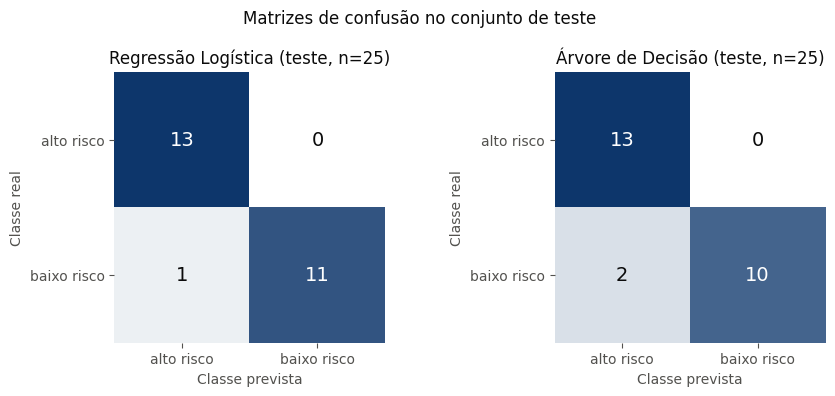

In [11]:
# Matrizes de confusao no teste dos dois modelos principais (linhas: classe real; colunas: classe prevista)
CLASSES = ["alto risco", "baixo risco"]
modelo_principal = modelos["Regressão Logística"]
modelo_arvore = modelos["Árvore de Decisão"]
mapa_azul = matplotlib.colors.LinearSegmentedColormap.from_list("azul", ["#ffffff", "#0d366b"])

fig, eixos = plt.subplots(1, 2, figsize=(9, 4))
for eixo, (nome, pipeline) in zip(eixos, [("Regressão Logística", modelo_principal),
                                          ("Árvore de Decisão", modelo_arvore)]):
    matriz = confusion_matrix(y_teste, pipeline.predict(X_teste), labels=CLASSES)
    eixo.imshow(matriz, cmap=mapa_azul, vmin=0, vmax=matriz.max())
    for i in range(2):
        for j in range(2):
            eixo.text(j, i, matriz[i, j], ha="center", va="center", fontsize=14,
                      color="white" if matriz[i, j] > matriz.max() / 2 else TEXTO)
    eixo.set_xticks([0, 1], CLASSES)
    eixo.set_yticks([0, 1], CLASSES)
    eixo.set_xlabel("Classe prevista")
    eixo.set_ylabel("Classe real")
    eixo.set_title(f"{nome} (teste, n={len(y_teste)})")
    eixo.spines[:].set_visible(False)
fig.suptitle("Matrizes de confusão no conjunto de teste", color=TEXTO)
fig.tight_layout()
fig.savefig(DIR_ASSETS / "matriz_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Relatorio por classe (precisao, sensibilidade, F1) e contagem dos erros mais graves da triagem
for nome, pipeline in [("Regressão Logística", modelo_principal), ("Árvore de Decisão", modelo_arvore)]:
    print(f"=== {nome}: relatorio de classificacao no teste ===")
    print(classification_report(y_teste, pipeline.predict(X_teste), labels=CLASSES, digits=3))

matriz_lr = confusion_matrix(y_teste, modelo_principal.predict(X_teste), labels=CLASSES)
print(f"Regressao Logistica: falsos negativos em 'alto risco' (casos graves previstos como baixo risco) = "
      f"{matriz_lr[0, 1]} de {matriz_lr[0].sum()}; falsos positivos (baixo risco previstos como alto) = "
      f"{matriz_lr[1, 0]} de {matriz_lr[1].sum()}")

# Lista as frases do teste em que a Regressao Logistica errou, com a probabilidade estimada
indice_alto = CLASSES.index("alto risco")
erros_teste = pd.DataFrame({"frase": X_teste, "real": y_teste,
                            "prevista": modelo_principal.predict(X_teste),
                            "prob. alto risco": modelo_principal.predict_proba(X_teste)[:, indice_alto].round(2)})
erros_teste = erros_teste[erros_teste["real"] != erros_teste["prevista"]].reset_index(drop=True)
print("\nFrases do teste classificadas incorretamente pela Regressao Logistica:")
display(erros_teste)

joblib.dump(modelo_principal, DIR_MODELOS / "modelo_risco.joblib")  # pipeline completo (TF-IDF + modelo) para reuso
print("Modelo principal gravado em src/models/modelo_risco.joblib")

=== Regressão Logística: relatorio de classificacao no teste ===
              precision    recall  f1-score   support

  alto risco      0.929     1.000     0.963        13
 baixo risco      1.000     0.917     0.957        12

    accuracy                          0.960        25
   macro avg      0.964     0.958     0.960        25
weighted avg      0.963     0.960     0.960        25

=== Árvore de Decisão: relatorio de classificacao no teste ===
              precision    recall  f1-score   support

  alto risco      0.867     1.000     0.929        13
 baixo risco      1.000     0.833     0.909        12

    accuracy                          0.920        25
   macro avg      0.933     0.917     0.919        25
weighted avg      0.931     0.920     0.919        25

Regressao Logistica: falsos negativos em 'alto risco' (casos graves previstos como baixo risco) = 0 de 13; falsos positivos (baixo risco previstos como alto) = 1 de 12

Frases do teste classificadas incorretamente pela

,frase,real,prevista,prob. alto risco
0,"Cansaço normal depois de uma caminhada longa, sem dor no peito nem falta de ar.",baixo risco,alto risco,0.5


Modelo principal gravado em src/models/modelo_risco.joblib


## 8. Interpretabilidade

Na Regressão Logística, cada termo do vocabulário recebe um coeficiente: valores negativos empurram a previsão para `alto risco` e valores positivos para `baixo risco` (a classe de referência positiva do modelo é `baixo risco`, a segunda em ordem alfabética). Os termos de maior peso mostram o que o modelo "aprendeu" a considerar sinal de alarme e sinal de tranquilidade. A figura é gravada em `assets/termos_relevantes.png`.

Na Árvore de Decisão, `export_text` imprime as regras aprendidas, que podem ser lidas como um protocolo de triagem simplificado.

Vocabulario do modelo (ajustado no treino): 138 termos


,termo (alto risco),coeficiente,termo (baixo risco),coeficiente
0,ar,-0.774,depois,0.964
1,falta,-0.774,quando,0.962
2,falta ar,-0.774,leve,0.927
3,peito,-0.739,pouco,0.669
4,suor,-0.683,mas,0.587
5,fraqueza,-0.601,muscular,0.509
6,desmaiei,-0.575,tenho,0.491
7,acordei,-0.486,barriga,0.452
8,suor frio,-0.468,normal,0.451
9,hora,-0.462,sem,0.421


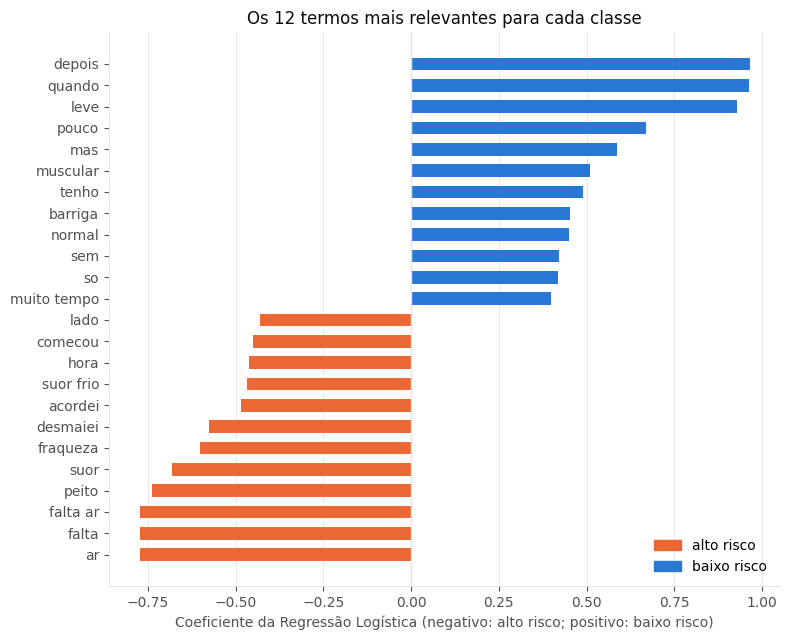

In [13]:
vetorizador_lr = modelo_principal.named_steps["tfidf"]
classificador_lr = modelo_principal.named_steps["clf"]
assert list(classificador_lr.classes_) == CLASSES
coeficientes = pd.Series(classificador_lr.coef_[0], index=vetorizador_lr.get_feature_names_out())
N_TERMOS = 12
termos_alto = coeficientes.nsmallest(N_TERMOS)      # mais negativos: alto risco
termos_baixo = coeficientes.nlargest(N_TERMOS)      # mais positivos: baixo risco

tabela_coef = pd.DataFrame({
    "termo (alto risco)": termos_alto.index, "coeficiente": termos_alto.values.round(3),
    "termo (baixo risco)": termos_baixo.index, "coeficiente ": termos_baixo.values.round(3),
})
print(f"Vocabulario do modelo (ajustado no treino): {len(coeficientes)} termos")
display(tabela_coef)

serie = pd.concat([termos_alto.sort_values(), termos_baixo.sort_values()])
cores_barras = [CORES["alto risco"] if v < 0 else CORES["baixo risco"] for v in serie.values]
fig, eixo = plt.subplots(figsize=(8, 6.5))
eixo.barh(serie.index, serie.values, color=cores_barras, height=0.6)
eixo.axvline(0, color=GRADE, linewidth=1)
eixo.set_xlabel("Coeficiente da Regressão Logística (negativo: alto risco; positivo: baixo risco)")
eixo.set_title(f"Os {N_TERMOS} termos mais relevantes para cada classe")
eixo.grid(axis="x", color=GRADE, linewidth=0.6)
eixo.set_axisbelow(True)
eixo.legend(handles=[Patch(color=CORES["alto risco"], label="alto risco"),
                     Patch(color=CORES["baixo risco"], label="baixo risco")], frameon=False, loc="lower right")
fig.tight_layout()
fig.savefig(DIR_ASSETS / "termos_relevantes.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
# Regras legiveis da arvore: cada divisao usa o peso TF-IDF de um termo
vetorizador_arvore = modelo_arvore.named_steps["tfidf"]
arvore = modelo_arvore.named_steps["clf"]
regras = export_text(arvore, feature_names=list(vetorizador_arvore.get_feature_names_out()),
                     class_names=CLASSES, decimals=2)
print("Regras da Arvore de Decisao (profundidade maxima 4):")
print(regras)
print(f"Numero de folhas: {arvore.get_n_leaves()} | termos usados nas divisoes: "
      f"{sorted(set(vetorizador_arvore.get_feature_names_out()[i] for i in arvore.tree_.feature if i >= 0))}")

Regras da Arvore de Decisao (profundidade maxima 4):
|--- depois <= 0.11
|   |--- quando <= 0.14
|   |   |--- leve <= 0.12
|   |   |   |--- mas <= 0.17
|   |   |   |   |--- class: alto risco
|   |   |   |--- mas >  0.17
|   |   |   |   |--- class: baixo risco
|   |   |--- leve >  0.12
|   |   |   |--- class: baixo risco
|   |--- quando >  0.14
|   |   |--- class: baixo risco
|--- depois >  0.11
|   |--- repentina <= 0.31
|   |   |--- foi <= 0.34
|   |   |   |--- class: baixo risco
|   |   |--- foi >  0.34
|   |   |   |--- class: alto risco
|   |--- repentina >  0.31
|   |   |--- class: alto risco

Numero de folhas: 7 | termos usados nas divisoes: ['depois', 'foi', 'leve', 'mas', 'quando', 'repentina']


## 9. Testes comportamentais com frases inéditas

Duas fontes de teste, nenhuma delas usada no treino nem na escolha de parâmetros:

1. `data/frases_teste.csv`: 20 frases inéditas, 10 por classe, organizadas por categoria (alto risco claro, baixo risco claro, apresentação atípica, ambíguas, negadas, com erro de digitação e em linguagem regional). As categorias vêm da lista `FRASES_TESTE` de `scripts/gerar_frases_risco.py`;
2. frases digitadas na hora, na célula seguinte, para observar a classe prevista e a probabilidade estimada pela Regressão Logística.

A probabilidade exibida é a estimativa do modelo para a classe `alto risco`; valores próximos de 0,5 indicam decisão incerta.

In [15]:
# Frases ineditas (nunca usadas no treino) com a categoria de cada uma, vinda do gerador da base
from gerar_frases_risco import FRASES_TESTE

df_teste = pd.read_csv(DIR_DADOS / "frases_teste.csv")
assert list(df_teste.columns) == ["frase", "situacao"]
assert list(df_teste["frase"]) == [f for f, _, _ in FRASES_TESTE], "ordem do CSV difere da lista de categorias"
df_teste["categoria"] = [c for _, _, c in FRASES_TESTE]

# Previsoes dos dois modelos e acerto frase a frase
df_teste["prevista (RL)"] = modelo_principal.predict(df_teste["frase"])
df_teste["prob. alto risco (RL)"] = modelo_principal.predict_proba(df_teste["frase"])[:, indice_alto].round(2)
df_teste["prevista (Árvore)"] = modelo_arvore.predict(df_teste["frase"])
df_teste["acerto (RL)"] = np.where(df_teste["prevista (RL)"] == df_teste["situacao"], "sim", "NAO")
df_teste["acerto (Árvore)"] = np.where(df_teste["prevista (Árvore)"] == df_teste["situacao"], "sim", "NAO")
display(df_teste[["categoria", "frase", "situacao", "prevista (RL)", "prob. alto risco (RL)", "acerto (RL)",
                  "prevista (Árvore)", "acerto (Árvore)"]])

acuracia_rl = accuracy_score(df_teste["situacao"], df_teste["prevista (RL)"])
acuracia_arvore = accuracy_score(df_teste["situacao"], df_teste["prevista (Árvore)"])
sens_rl = recall_score(df_teste["situacao"], df_teste["prevista (RL)"], pos_label="alto risco")
sens_arvore = recall_score(df_teste["situacao"], df_teste["prevista (Árvore)"], pos_label="alto risco")
print(f"Frases ineditas (n=20): acuracia RL = {acuracia_rl:.2f} | sensibilidade alto risco RL = {sens_rl:.2f}")
print(f"                        acuracia Arvore = {acuracia_arvore:.2f} | sensibilidade alto risco Arvore = {sens_arvore:.2f}")
print("\nAcertos da Regressao Logistica por categoria:")
print(df_teste.groupby("categoria")["acerto (RL)"].apply(lambda s: f"{(s == 'sim').sum()}/{len(s)}").to_string())

,categoria,frase,situacao,prevista (RL),prob. alto risco (RL),acerto (RL),prevista (Árvore),acerto (Árvore)
0,alto risco claro,"Dor esmagadora no peito irradiando para o braço esquerdo, com suor frio e falta de ar.",alto risco,alto risco,0.82,sim,alto risco,sim
1,alto risco claro,Minha fala embolou de repente e não consigo levantar o braço direito.,alto risco,alto risco,0.65,sim,alto risco,sim
2,alto risco claro,Desmaiei no trabalho e acordei com o coração disparado.,alto risco,alto risco,0.61,sim,alto risco,sim
3,alto risco claro,"Não consigo respirar, comecei a ficar sem ar do nada e o peito está apertado.",alto risco,alto risco,0.63,sim,alto risco,sim
4,apresentação atípica,"Sou diabético e sinto um mal estar forte com suor frio e enjoo, sem dor no peito.",alto risco,alto risco,0.63,sim,alto risco,sim
5,baixo risco claro,Dor de cabeça leve depois de passar o dia no sol.,baixo risco,baixo risco,0.26,sim,baixo risco,sim
6,baixo risco claro,"Azia depois de comer feijoada, melhora com leite.",baixo risco,baixo risco,0.31,sim,baixo risco,sim
7,baixo risco claro,"Dor no peito só quando aperto o lugar, depois da musculação.",baixo risco,baixo risco,0.32,sim,baixo risco,sim
8,baixo risco claro,"Cansaço normal depois de uma semana de trabalho pesado, sem outros sintomas.",baixo risco,baixo risco,0.28,sim,baixo risco,sim
9,baixo risco claro,"Coração acelerado depois de três cafés, passou em dez minutos.",baixo risco,baixo risco,0.47,sim,baixo risco,sim


Frases ineditas (n=20): acuracia RL = 0.85 | sensibilidade alto risco RL = 0.90
                        acuracia Arvore = 0.90 | sensibilidade alto risco Arvore = 0.90

Acertos da Regressao Logistica por categoria:
categoria
alto risco claro        4/4
ambígua                 1/3
apresentação atípica    1/1
baixo risco claro       5/5
erro de digitação       2/2
linguagem regional      2/2
negada                  2/3


In [16]:
frases_digitadas = [
    "Dor no peito muito forte com suor frio, começou agora.",                      # alto risco claro
    "Estou com uma dor de cabeça leve depois de um dia cansativo.",                # baixo risco claro
    "Uma pontada no peito que vai e volta há alguns dias, sem outros sintomas.",   # ambigua
    "Não sinto dor no peito nem falta de ar, apenas um cansaço leve.",             # negada (baixo)
    "Não é azia, é uma dor apertando o peito com suor frio.",                      # negada (alto)
    "Dor no peto e falta de ár, com suor frio.",                                   # erro de digitacao
    "Tô com uma agonia no peito e o braço adormecido, vixe.",                      # regional
    "Minha vó ficou com a boca torta e a fala embolada de repente.",               # terceira pessoa
]
previsoes = modelo_principal.predict(frases_digitadas)
probabilidades = modelo_principal.predict_proba(frases_digitadas)[:, indice_alto]
display(pd.DataFrame({"frase": frases_digitadas, "classe prevista": previsoes,
                      "prob. alto risco": probabilidades.round(2)}))

,frase,classe prevista,prob. alto risco
0,"Dor no peito muito forte com suor frio, começou agora.",alto risco,0.75
1,Estou com uma dor de cabeça leve depois de um dia cansativo.,baixo risco,0.27
2,"Uma pontada no peito que vai e volta há alguns dias, sem outros sintomas.",baixo risco,0.50
3,"Não sinto dor no peito nem falta de ar, apenas um cansaço leve.",alto risco,0.56
4,"Não é azia, é uma dor apertando o peito com suor frio.",alto risco,0.67
5,"Dor no peto e falta de ár, com suor frio.",alto risco,0.81
6,"Tô com uma agonia no peito e o braço adormecido, vixe.",alto risco,0.64
7,Minha vó ficou com a boca torta e a fala embolada de repente.,alto risco,0.58


## 10. Padrões e distorções observados

Os experimentos abaixo isolam comportamentos típicos de um classificador de texto baseado em palavras-chave: cegueira à negação, dependência de termos específicos, efeito de termos raros e sobreajuste. Cada bloco imprime a probabilidade estimada de `alto risco`.

In [17]:
def prob_alto(frases):
    """Probabilidade de alto risco estimada pela Regressao Logistica para uma lista de frases."""
    return modelo_principal.predict_proba(list(frases))[:, indice_alto]


def mostrar(titulo, frases):
    """Imprime cada frase com a probabilidade de alto risco, para comparar variantes lado a lado."""
    print(f"--- {titulo} ---")
    for frase, p in zip(frases, prob_alto(frases)):
        print(f"  {p:.2f}  {frase}")
    print()


mostrar("1. Negacao: a mesma frase afirmada e negada", [
    "Sinto dor no peito e suor frio.",
    "Não sinto dor no peito nem suor frio.",
    "Nunca tive dor no peito, suor frio ou falta de ar.",
    "Sem dor no peito, sem suor frio, sem falta de ar.",
])
mostrar("2. Dependencia de palavras-chave: gravidade sem o vocabulario esperado", [
    "Dor no peito.",
    "Estou muito mal, preciso de ajuda urgente, acho que vou morrer.",
    "Meu marido caiu no chão e não responde, o rosto está roxo.",
    "Um leve incômodo no peito depois de rir muito.",
])
mostrar("3. Termos raros, regionais e erros de digitacao", [
    "Dor no peito com suor frio.",
    "Dor no peto com suor frio.",
    "Agonia no peito com suadouro frio.",
    "Batedeira no peito e a vista escurecendo.",
])
mostrar("4. Contexto que muda o rotulo com quase as mesmas palavras", [
    "Coração acelerado durante o treino, volta ao normal quando paro.",
    "Coração acelerado em repouso, com tontura, não volta ao normal.",
])

# Sobreajuste: distancia entre a acuracia de treino e a de validacao cruzada
sobreajuste = tabela_resultados.loc["Regressão Logística", "acurácia treino (CV)"] - \
              tabela_resultados.loc["Regressão Logística", "acurácia CV (média)"]
print(f"Sobreajuste (acuracia de treino menos acuracia de validacao cruzada, Regressao Logistica): {sobreajuste:.3f}")
print(f"Diferenca entre acuracia CV e acuracia no teste (Regressao Logistica): "
      f"{tabela_resultados.loc['Regressão Logística', 'acurácia CV (média)'] - tabela_resultados.loc['Regressão Logística', 'acurácia teste']:.3f}")

--- 1. Negacao: a mesma frase afirmada e negada ---
  0.66  Sinto dor no peito e suor frio.
  0.62  Não sinto dor no peito nem suor frio.
  0.80  Nunca tive dor no peito, suor frio ou falta de ar.
  0.61  Sem dor no peito, sem suor frio, sem falta de ar.

--- 2. Dependencia de palavras-chave: gravidade sem o vocabulario esperado ---
  0.59  Dor no peito.
  0.46  Estou muito mal, preciso de ajuda urgente, acho que vou morrer.
  0.54  Meu marido caiu no chão e não responde, o rosto está roxo.
  0.33  Um leve incômodo no peito depois de rir muito.

--- 3. Termos raros, regionais e erros de digitacao ---
  0.72  Dor no peito com suor frio.
  0.69  Dor no peto com suor frio.
  0.66  Agonia no peito com suadouro frio.
  0.62  Batedeira no peito e a vista escurecendo.

--- 4. Contexto que muda o rotulo com quase as mesmas palavras ---
  0.39  Coração acelerado durante o treino, volta ao normal quando paro.
  0.53  Coração acelerado em repouso, com tontura, não volta ao normal.

Sobreajuste (a

### Leitura dos experimentos

| Padrão | Evidência nas células acima | Implicação em uma triagem real |
|---|---|---|
| **Cegueira à negação** | "Sinto dor no peito e suor frio" recebe 0,66 de probabilidade de alto risco; a versão negada, "Não sinto dor no peito nem suor frio", recebe 0,62; "Nunca tive dor no peito, suor frio ou falta de ar" sobe a 0,80 e "Sem dor no peito, sem suor frio, sem falta de ar" fica em 0,61. As quatro são classificadas como alto risco. O único erro da Regressão Logística no conjunto de teste é uma frase de baixo risco que nega sintomas ("Cansaço normal depois de uma caminhada longa, sem dor no peito nem falta de ar", 0,50), e no conjunto inédito "Não sinto dor no peito nem falta de ar, apenas uma dor muscular nas costas" também vai para alto risco (0,52). O TF-IDF registra que "nao" e "sem" apareceram, mas não sabe a que termo se referem; os bigramas "nao sinto" e "sem dor" ajudam só quando a negação vem imediatamente antes do termo | Um paciente que escreve "não tenho dor no peito" pode ser encaminhado como grave. O erro é conservador (falso positivo), mas em escala consome recursos e reduz a confiança na ferramenta. O extrator da Parte 1, com regra de negação por janela, é justamente o componente que cobre essa falha na função `triagem` |
| **Dependência de palavras-chave** | "Dor no peito." sozinha recebe 0,59; "Estou muito mal, preciso de ajuda urgente, acho que vou morrer" recebe 0,46 e é classificada como baixo risco; "Meu marido caiu no chão e não responde, o rosto está roxo" fica em 0,54, apesar de descreverem emergências. Sem os termos vistos no treino ("suor", "falta ar", "desmaiei"), o modelo fica no limiar da decisão | Descrições de emergência que não usam o vocabulário do treino são subestimadas. A regra prática de qualquer triagem automática permanece: quando o sistema não reconhece o quadro, a saída deve ser encaminhar, não tranquilizar |
| **Sensibilidade a termos raros e contexto** | Os termos de maior peso para baixo risco são "depois", "quando", "leve", "pouco" e "mas", e para alto risco "ar", "falta", "falta ar", "peito", "suor" e "fraqueza". Com `min_df=2`, o vocabulário caiu de 1.057 para 192 termos; a lista ampla de stopwords, que apagava "depois" e "quando", derrubou a acurácia da validação cruzada de 0,853 para 0,760 | O modelo aprendeu marcadores de contexto (relação com esforço, alimentação, tempo) tanto quanto sintomas. Isso é desejável, mas frágil: "Coração acelerado em repouso, com tontura, não volta ao normal" (0,53) e "Coração acelerado durante o treino, volta ao normal quando paro" (0,39) são separadas, mas por margem pequena, porque "coração acelerado" aparece nas duas classes do treino |
| **Robustez a erros de digitação e regionalismos** | "Dor no peto com suor frio" (0,69) e "Agonia no peito com suadouro frio" (0,66) ficam próximas da frase padrão (0,72); no conjunto inédito, as categorias "erro de digitação" e "linguagem regional" tiveram 2/2 acertos cada | A remoção de acentos e a redundância entre termos (basta um dos sinais ser reconhecido) dão alguma tolerância, mas ela depende de a frase conter ao menos um termo conhecido: "suadouro" só não prejudicou porque "frio" e "peito" estavam presentes |
| **Decisões pouco confiantes** | A regularização escolhida por validação cruzada (`C=1`) comprime as probabilidades: 11 das 20 frases inéditas receberam probabilidades entre 0,40 e 0,65, e dois relatos da Parte 1 caíram exatamente em 0,50 | Em uma triagem real, probabilidades perto do limiar deveriam ser tratadas como "incerto, encaminhar", e não como uma decisão binária |
| **Efeito do balanceamento** | A base é artificialmente 50/50 e `class_weight="balanced"` preserva esse equilíbrio nas partições. No teste, a Árvore de Decisão atingiu sensibilidade 1,00 para alto risco ao custo de 2 das 12 frases leves encaminhadas como graves (sensibilidade 0,833 para baixo risco); o Naive Bayes acertou as 25 frases, resultado que em um conjunto tão pequeno não diferencia os modelos | Em uma população real, em que a maioria das queixas é de baixo risco, um modelo assim geraria muitos alarmes falsos; a calibração do limiar de decisão precisaria ser feita com a prevalência real e com o custo de cada tipo de erro |
| **Sobreajuste e variância em base pequena** | Acurácia de treino 0,983 contra 0,853 na validação cruzada (diferença de 0,130), com desvio de 0,142 entre as cinco partições de 15 frases; o conjunto de teste de 25 frases, por sua vez, deu 0,96, acima da própria validação cruzada (diferença de 0,107 no sentido oposto). Com 25 frases, cada erro vale 4 pontos percentuais | As métricas de uma base de 100 frases são estimativas grosseiras e dependem de qual conjunto de frases caiu em cada partição. O desempenho em relatos reais seria menor e desconhecido |

A regra de ouro extraída desses experimentos: **o erro mais grave é o falso negativo em alto risco**. Ele não ocorreu nas 13 frases graves do teste, mas ocorreu em uma das 10 frases graves inéditas ("Um cansaço diferente há uma semana, com as pernas inchando no fim do dia", 0,42), um quadro sugestivo de insuficiência cardíaca descrito sem os termos de alarme aprendidos. Uma triagem real precisaria de mais exemplos dessas apresentações, de um limiar de decisão deslocado em favor do encaminhamento e de supervisão humana obrigatória.

## 11. Integração das Partes 1 e 2: a função `triagem(frase)`

O extrator da Parte 1 (`src/extrator_sintomas.py`) é importado diretamente, sem cópia de código, para que a demonstração no vídeo seja única e o comportamento do notebook seja idêntico ao da execução por terminal (`python src/extrator_sintomas.py`). As funções centrais são exibidas abaixo com `inspect.getsource`.

A função `triagem(frase)` combina as duas partes: os sintomas reconhecidos e negados, a hipótese diagnóstica sugerida pelo mapa de conhecimento (Parte 1) e o nível de risco com a probabilidade estimada pela Regressão Logística (Parte 2). Cada componente cobre uma fraqueza do outro: o extrator entende negação simples e explica quais expressões encontrou; o classificador generaliza para frases sem expressões do mapa.

In [18]:
# Importa o extrator da Parte 1 (src/extrator_sintomas.py) e exibe suas funcoes centrais
import extrator_sintomas as extrator

for funcao in (extrator.normalizar_texto, extrator.verificar_negacao, extrator.sugerir_diagnostico):
    print(inspect.getsource(funcao))

def normalizar_texto(texto):
    """Normaliza um texto para comparacao: minusculas, sem acentos, sem
    pontuacao e sem espacos repetidos.

    A mesma funcao e aplicada aos relatos e as expressoes do mapa, de modo
    que "coração acelerado" e "coracao acelerado" sejam tratados como iguais.
    """
    texto = texto.lower()
    texto = unicodedata.normalize("NFKD", texto)
    texto = "".join(c for c in texto if not unicodedata.combining(c))
    texto = re.sub(r"[^a-z0-9\s]", " ", texto)  # pontuacao vira espaco
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto

def verificar_negacao(frase_normalizada, inicio, janela=JANELA_NEGACAO):
    """Indica se ha uma palavra de negacao nas `janela` palavras que
    antecedem a posicao `inicio` da frase normalizada.

    Limitacao documentada: a regra nao entende o escopo real da negacao.
    "nao tenho febre, mas sinto dor no peito" e tratado corretamente porque
    "nao" fica a mais de tres palavras de "dor", mas "nao sinto mais 

In [19]:
MAPA_DOENCAS, FORMA_ORIGINAL = extrator.carregar_mapa()
PADROES = extrator.compilar_padroes(MAPA_DOENCAS.keys())
print(f"Mapa de conhecimento carregado: {len(MAPA_DOENCAS)} expressoes, "
      f"{len({d for ds in MAPA_DOENCAS.values() for d in ds})} doencas.")


def triagem(frase, modelo=modelo_principal):
    """Combina o extrator de sintomas (Parte 1) com o classificador de risco (Parte 2).

    Devolve um dicionario com: sintomas identificados e negados, diagnostico sugerido,
    hipoteses alternativas, nivel de risco previsto e probabilidade de alto risco.
    Uso academico: a decisao clinica e sempre do profissional de saude.
    """
    parte1 = extrator.analisar_frase(frase, MAPA_DOENCAS, FORMA_ORIGINAL, PADROES)
    probabilidade_alto = float(modelo.predict_proba([frase])[0][indice_alto])
    return {
        "frase": frase,
        "sintomas": "; ".join(parte1["sintomas_identificados"]) or "(nenhum reconhecido)",
        "negados": "; ".join(parte1["sintomas_negados"]),
        "hipotese": parte1["diagnostico_sugerido"],
        "alternativas": "; ".join(parte1["hipoteses_alternativas"]),
        "risco": modelo.predict([frase])[0],
        "prob. alto risco": round(probabilidade_alto, 2),
    }


relatos = extrator.carregar_relatos()
tabela_triagem = pd.DataFrame([triagem(frase) for frase in relatos])
tabela_triagem.index = range(1, len(relatos) + 1)
display(tabela_triagem)

Mapa de conhecimento carregado: 108 expressoes, 12 doencas.


,frase,sintomas,negados,hipotese,alternativas,risco,prob. alto risco
1,"Desde ontem à noite sinto uma dor no peito muito forte, com suor frio e formigamento no braço esquerdo; ho...",dor no peito; suor frio; formigamento no braço,,Infarto,Arritmia (1); Síncope (1),alto risco,0.65
2,Faz umas três semanas que sinto aperto no peito ao subir escada e cansaço ao caminhar depressa; melhora co...,aperto no peito ao subir escada; cansaço ao caminhar; melhora com repouso,,Angina,Insuficiência Cardíaca (1),baixo risco,0.47
3,"De uns dois meses para cá estou com as pernas inchadas, uma canseira danada e acordo com falta de ar de ma...",pernas inchadas; canseira; acordo com falta de ar,,Insuficiência Cardíaca,,alto risco,0.65
4,"Há uns dez dias, no meio do treino de corrida, sinto o coração acelerado do nada, com batedeira e tontura;...",coração acelerado; batedeira; tontura,,Arritmia,Ansiedade (1); Hipertensão (1),baixo risco,0.50
5,"Nos últimos quinze dias estou com a pressão alta, dor na nuca e zumbido no ouvido quase todo dia; no servi...",pressão alta; dor na nuca; zumbido no ouvido,,Hipertensão,,alto risco,0.50
6,"Hoje de manhã, de repente, fiquei com a fala enrolada, a boca torta e fraqueza no braço direito; não conse...",fala enrolada; boca torta; fraqueza no braço,,AVC,,alto risco,0.57
7,"Ontem, depois de ficar em pé no sol na fila do banco, senti vista escura e suor frio e tive um desmaio; ho...",vista escura; suor frio; desmaio,,Síncope,Arritmia (1); Hipertensão (1); Infarto (1),alto risco,0.52
8,"Desde anteontem, depois de jantar tarde, sinto queimação no peito e azia quando deito, com gosto amargo na...",queimação no peito; azia; gosto amargo na boca,,Refluxo,Infarto (1),baixo risco,0.31
9,"Faz quatro dias que sinto dor no peito ao apertar e dor ao mover o braço, depois de um treino pesado de mu...",dor no peito ao apertar; dor ao mover o braço,falta de ar,Dor Musculoesquelética,,alto risco,0.59
10,"Há um mês, sempre antes das reuniões, fico com o coração acelerado, formigamento nas mãos e uma sensação d...",coração acelerado; formigamento nas mãos; sensação de sufoco,,Ansiedade,Arritmia (1),baixo risco,0.43


In [20]:
# Validacao do extrator contra o gabarito (mesma verificacao feita por python src/extrator_sintomas.py)
resultados_extrator = extrator.processar_relatos(relatos, MAPA_DOENCAS, FORMA_ORIGINAL, PADROES)
taxa_acerto_extrator = extrator.comparar_com_gabarito(resultados_extrator)

 #  Esperado                 Sugerido                 Acerto
 1  Infarto                  Infarto                  sim
 2  Angina                   Angina                   sim
 3  Insuficiência Cardíaca   Insuficiência Cardíaca   sim
 4  Arritmia                 Arritmia                 sim
 5  Hipertensão              Hipertensão              sim
 6  AVC                      AVC                      sim
 7  Síncope                  Síncope                  sim
 8  Refluxo                  Refluxo                  sim
 9  Dor Musculoesquelética   Dor Musculoesquelética   sim
10  Ansiedade                Ansiedade                sim

Taxa de acerto do diagnostico sugerido: 10/10 = 100%
Cobertura dos sintomas esperados: 29/29 = 100%


In [21]:
# Demonstracao com as duas frases-exemplo da Parte 1 do enunciado e com frases digitadas
# (a terceira provoca empate de hipoteses no extrator; a quarta combina negacao e sintomas)
for frase in ["Há dois dias estou com uma dor no peito que piora quando faço esforço físico",
              "Sinto cansaço constante há uma semana, mesmo depois de descansar",
              "Sinto queimação no peito e dor de cabeça desde ontem.",
              "Não sinto dor no peito, mas estou com falta de ar e as pernas inchadas."]:
    resultado = triagem(frase)
    print(textwrap.fill(f"Frase: {resultado['frase']}", 110))
    for chave in ("sintomas", "negados", "hipotese", "alternativas", "risco", "prob. alto risco"):
        print(f"  {chave:>16}: {resultado[chave]}")
    print()

Frase: Há dois dias estou com uma dor no peito que piora quando faço esforço físico
          sintomas: dor no peito que piora quando faço esforço
           negados: 
          hipotese: Angina
      alternativas: 
             risco: baixo risco
  prob. alto risco: 0.44

Frase: Sinto cansaço constante há uma semana, mesmo depois de descansar
          sintomas: cansaço constante; mesmo depois de descansar
           negados: 
          hipotese: Insuficiência Cardíaca
      alternativas: 
             risco: baixo risco
  prob. alto risco: 0.4

Frase: Sinto queimação no peito e dor de cabeça desde ontem.
          sintomas: queimação no peito; dor de cabeça
           negados: 
          hipotese: Hipertensão ou Infarto ou Refluxo
      alternativas: Hipertensão (1); Infarto (1); Refluxo (1)
             risco: baixo risco
  prob. alto risco: 0.45

Frase: Não sinto dor no peito, mas estou com falta de ar e as pernas inchadas.
          sintomas: falta de ar; pernas inchadas
         

## 12. Conclusões, limitações, ética e governança

### Conclusões

1. A Parte 1 (extração por regras) e a Parte 2 (classificação por TF-IDF) funcionam de ponta a ponta e se complementam. O extrator reconheceu os 29 sintomas esperados dos dez relatos e sugeriu o diagnóstico esperado em 10 de 10 casos, com a hipótese de menor gravidade quando cabia (refluxo, dor musculoesquelética, ansiedade). O classificador principal, Regressão Logística com TF-IDF de unigramas e bigramas, alcançou acurácia média de 0,853 (desvio 0,142) na validação cruzada estratificada, 0,96 no conjunto de teste de 25 frases (sensibilidade 1,00 para alto risco) e 0,85 nas 20 frases inéditas dos testes comportamentais (sensibilidade 0,90).
2. As decisões de pré-processamento foram medidas, não presumidas: manter "não", "sem", "nem" e "nunca" e os marcadores de contexto ("depois", "quando", "agora", "só") elevou a acurácia da validação cruzada de 0,760 (lista ampla de stopwords) para 0,853 (lista mínima), e remover nada ficou em 0,773; exigir `min_df=2` reduziu o vocabulário de 1.057 para 192 termos; `C=1` foi o valor de regularização escolhido na busca em grade (empatado com `C=3`, prevalece o mais simples).
3. A Árvore de Decisão produziu regras legíveis com seis termos ("depois", "quando", "leve", "mas", "foi", "repentina") e desempenho inferior na validação cruzada (0,693), embora tenha acertado 0,92 no teste e 0,90 nas frases inéditas. O Naive Bayes ficou em 0,813 na validação cruzada e acertou as 25 frases do teste. Nesta base, a representação importa mais que o algoritmo, e um resultado perfeito em 25 frases não é evidência de superioridade.
4. A função `triagem(frase)` mostrou os dois componentes discordando de forma instrutiva: no relato 2 (angina de esforço) e no relato 4 (arritmia), o extrator apontou a hipótese cardíaca correta enquanto o classificador ficou em 0,47 e 0,50, influenciado por marcadores de contexto ("melhora com repouso", "treino"); no relato 9 (dor muscular) ocorreu o inverso (0,59 de alto risco). As duas frases-exemplo da Parte 1 do enunciado receberam do extrator as hipóteses esperadas (Angina para a dor no peito que piora com esforço e Insuficiência Cardíaca para o cansaço constante), mas o classificador as estimou como baixo risco (0,44 e 0,40), porque "esforço físico" e "depois de descansar" se parecem com os marcadores de contexto das frases leves do treino. Em um sistema real, a discordância entre módulos deveria ser tratada como sinal de incerteza e encaminhada a um profissional.

### Limitações

- Base de 100 frases sintéticas (98 escritas pelo grupo e 2 exemplos literais do enunciado): vocabulário, estilo e distribuição de erros não representam relatos reais de pacientes, que são mais longos, digressivos e diversos em escolaridade e região.
- Rótulos atribuídos sem validação clínica independente, a partir de uma simplificação didática de sinais de alarme.
- Balanceamento artificial (50/50) e ausência de calibração de limiar para a prevalência real.
- Cegueira à negação e dependência de palavras-chave, demonstradas na seção 10; o extrator da Parte 1 mitiga a primeira apenas para negações em janela de até três palavras.
- Métricas com alta variância: 25 frases de teste e 5 partições de 15 frases, desvio de 0,142 na validação cruzada e diferença de 0,107 entre validação cruzada e teste.
- Sem variação demográfica controlada: não é possível afirmar que o modelo trata igualmente mulheres, idosos, diabéticos ou falantes de variantes regionais, embora as frases de apresentação atípica e de linguagem regional incluídas nos testes tenham sido classificadas corretamente.

### Ética e governança

- **Natureza dos dados.** Apenas frases simuladas, sem nome, documento, idade exata ou qualquer combinação de atributos que identifique uma pessoa; nenhum dado pessoal sensível (art. 5º, II, da LGPD) é tratado. O dataset numérico da Fase 1 (UCI Cleveland, CC BY 4.0), público e anonimizado na origem, foi usado apenas como referência de perfis e como base da análise de vieses documentada em `document/governanca_e_vieses.md`.
- **O que mudaria com dados reais.** Relatos reais de pacientes são dados pessoais sensíveis: exigiriam base legal específica (art. 11 da LGPD), consentimento ou tutela da saúde, anonimização ou pseudonimização, registro das operações de tratamento, avaliação de impacto e governança de acesso.
- **Vieses herdados.** A coorte da Fase 1 é de um único centro, dos anos 1980, com 68% de homens e 73% de doença coronariana entre os pacientes classificados como assintomáticos: um triador dependente de palavras-chave herda esse ponto cego e tende a subestimar apresentações atípicas, mais frequentes em mulheres, idosos e diabéticos.
- **Responsabilidade.** O sistema classifica risco para priorização e sugere hipóteses; a decisão é do profissional de saúde. Toda saída carrega o aviso de não substituição da avaliação médica, o registro dos termos e regras que motivaram a classificação (interpretabilidade da seção 8) e a mensagem padrão de encaminhamento quando nada é reconhecido.
- **Mitigações propostas.** Ampliar a base com relatos de redatores diversos e revisão clínica; incluir pares afirmativo/negativo no treino; tratar negação e escopo antes da vetorização; deslocar o limiar de decisão em favor do encaminhamento; medir sensibilidade por subgrupo (sexo, idade, registro linguístico); manter supervisão humana e trilha de auditoria. Detalhes em `document/governanca_e_vieses.md`.

## 13. Referências

BRASIL. **Lei nº 13.709, de 14 de agosto de 2018**. Lei Geral de Proteção de Dados Pessoais (LGPD). Diário Oficial da União: seção 1, Brasília, DF, 15 ago. 2018.

FIAP. **IA que entende: processamento de linguagem natural baseado em regras**. Capítulo 10 do material didático da Fase 2, 2º ano, curso de Inteligência Artificial. São Paulo: FIAP, 2025.

FIAP. **NLP no estilo clássico: estatística, vetores e emoções em texto**. Capítulo 11 do material didático da Fase 2, 2º ano, curso de Inteligência Artificial. São Paulo: FIAP, 2025.

FIAP. **IA responsável: ética, sustentabilidade e regulação na era dos dados**. Capítulo 7 do material didático da Fase 2, 2º ano, curso de Inteligência Artificial. São Paulo: FIAP, 2025.

GUERREIRO JUNIOR, S. P. **CardioIA, Fase 1: Batimentos de Dados** [repositório]. GitHub, 2026. Disponível em: https://github.com/silvioguerreiro/FIAP_1TIAOS_2026_Ano2_Fase1. Acesso em: 28 set. 2026.

JANOSI, A.; STEINBRUNN, W.; PFISTERER, M.; DETRANO, R. **Heart Disease** [conjunto de dados]. Irvine: UCI Machine Learning Repository, 1989. DOI: 10.24432/C52P4X. Disponível em: https://archive.ics.uci.edu/dataset/45/heart+disease. Acesso em: 15 ago. 2026.

JURAFSKY, D.; MARTIN, J. H. **Speech and language processing**. 3. ed. (rascunho). Stanford, 2025. Disponível em: https://web.stanford.edu/~jurafsky/slp3/. Acesso em: 28 set. 2026.

PEDREGOSA, F. et al. Scikit-learn: machine learning in Python. **Journal of Machine Learning Research**, v. 12, p. 2825-2830, 2011. Disponível em: https://jmlr.org/papers/v12/pedregosa11a.html. Acesso em: 28 set. 2026.

SCIKIT-LEARN. **User guide: TfidfVectorizer, LogisticRegression, DecisionTreeClassifier, GridSearchCV**. Versão 1.8. Disponível em: https://scikit-learn.org/stable/user_guide.html. Acesso em: 28 set. 2026.